# GeoCarb Observation Geometry — `geosat_geometry` Driver Notebook

This notebook walks through every major feature of `geosat_geometry.py`:

1. [Satellite setup](#1-satellite-setup)
2. [Single slit geometry](#2-single-slit-geometry)
3. [Building ScanBlocks](#3-building-scanblocks)
4. [Exploring ScanBlock structure](#4-exploring-scanblock-structure)
5. [Plotting scan blocks](#5-plotting-scan-blocks)
6. [Save and reload](#6-save-and-reload)
7. [Coarsening to a model grid](#7-coarsening-to-a-model-grid)
8. [Fine vs coarse comparison](#8-fine-vs-coarse-comparison)
9. [3-D ray tracing through the atmosphere](#9-3-d-ray-tracing-through-the-atmosphere)
10. [Ray tracing from a ScanBlock](#10-ray-tracing-from-a-scanblock)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from datetime import datetime, timedelta
import cartopy.crs as ccrs

from geosat_geometry import (
    LongSlitGeoSatellite,
    ScanBlock,
    plot_scan_blocks,
    coarsen_scan_block,
    geodetic_to_ecef,
    ecef_to_geodetic,
    solar_position_ecef,
)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

---
## 1 — Satellite Setup

Configure a GeoCarb-like instrument at −95° longitude with a 3000 km N-S slit,
6 km × 6 km pixels, and a 10-second integration time.

In [2]:
sat = LongSlitGeoSatellite(
    sat_lon_deg      = -95.0,   # sub-satellite longitude [°E]
    slit_length_km   = 3000.0,  # N-S slit length at nadir [km]
    pixel_size_ew_km =    6.0,  # E-W pixel size at nadir [km]
    pixel_size_ns_km =    6.0,  # N-S pixel size at nadir [km]
    integration_time_s = 10.0,  # one scan step [s]
)
print(sat)
print(f"  Satellite ECEF [km] : {sat.sat_ecef.round(1)}")
print(f"  Pixels along slit   : {sat.n_pixels}")
print(f"  IFOV E-W / N-S      : {np.degrees(sat.ifov_ew_rad)*60:.3f} / "
      f"{np.degrees(sat.ifov_ns_rad)*60:.3f} arcmin")
print(f"  Scan rate           : {sat.scan_rate_kms:.4f} km/s")

LongSlitGeoSatellite(lon=-95.0°, slit=3000 km × 500 px, pixel=6.0×6.0 km, τ=10.0s)
  Satellite ECEF [km] : [ -3674.8 -42003.7      0. ]
  Pixels along slit   : 500
  IFOV E-W / N-S      : 0.576 / 0.576 arcmin
  Scan rate           : 0.6000 km/s


---
## 2 — Single Slit Geometry

`slit_geometry_vectorized` computes the geometry for all pixels in a single
slit position.  Useful for quick checks before building a full ScanBlock.

In [3]:
dt = datetime(2020, 7, 1, 18, 0, 0)   # 18:00 UTC
geom = sat.slit_geometry_vectorized(30.0, -120.0, dt_utc=dt)

print("Slit geometry keys:", list(geom.keys()))
print(f"\nSouth pixel  lat={geom['lats'][ 0]:.2f}°  VZA={geom['vzas'][ 0]:.1f}°  SZA={geom['szas'][ 0]:.1f}°")
print(f"Centre pixel lat={geom['lats'][250]:.2f}°  VZA={geom['vzas'][250]:.1f}°  SZA={geom['szas'][250]:.1f}°")
print(f"North pixel  lat={geom['lats'][-1]:.2f}°  VZA={geom['vzas'][-1]:.1f}°  SZA={geom['szas'][-1]:.1f}°")

Slit geometry keys: ['lats', 'lons', 'vzas', 'vaas', 'szas', 'saas', 'look_vecs', 'sat_look_vecs', 'corner_lats', 'corner_lons', 'gnd_ecef', 'sat_ecef', 'airmass_geometric', 'relative_azimuth', 'valid_mask']

South pixel  lat=14.39°  VZA=30.3°  SZA=27.6°
Centre pixel lat=30.03°  VZA=44.4°  SZA=28.5°
North pixel  lat=51.82°  VZA=69.1°  SZA=44.5°


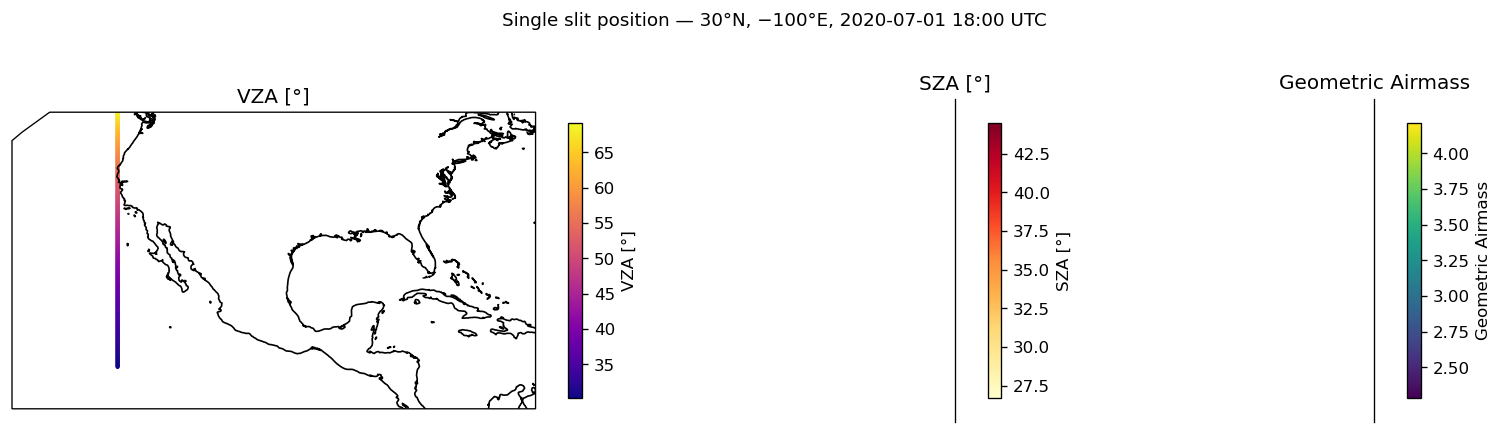

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True,subplot_kw={'projection': ccrs.Geostationary(central_longitude=-95.0)})
fields   = ['vzas',  'szas',  'airmass_geometric']
labels   = ['VZA [°]', 'SZA [°]', 'Geometric Airmass']
cmaps    = ['plasma',  'YlOrRd',  'viridis']

for ax, fld, lbl, cm in zip(axes, fields, labels, cmaps):
    sc = ax.scatter(geom['lons'], geom['lats'], c=geom[fld],
                    s=2, cmap=cm, transform=ccrs.PlateCarree(), norm=mcolors.Normalize(vmin=np.nanmin(geom[fld]), vmax=np.nanmax(geom[fld])))
    plt.colorbar(sc, ax=ax, label=lbl, shrink=0.85)
    ax.set_xlabel('Longitude [°E]')
    ax.set_title(lbl)
axes[0].set_ylabel('Latitude [°]')
axes[0].coastlines()
axes[0].set_extent([-130, -70, 10, 50], crs=ccrs.PlateCarree())
plt.suptitle('Single slit position — 30°N, −100°E, 2020-07-01 18:00 UTC',
             y=1.02, fontsize=11)
plt.tight_layout()

---
## 3 — Building ScanBlocks

`build_scan_block` computes the full 2-D geometry for a rectangular scan region
in a single vectorised pass.  Solar angles are advanced per column, matching
the real integration timeline.

In [5]:
import time

dt0 = datetime(2020, 7, 1, 17, 30, 0)

# Three adjacent blocks covering the continental US
block_defs = [
    ('West',    30.0, -120.0,  -95.0),
    ('Central', 30.0,  -95.0,  -75.0),
    ('East',    30.0,  -75.0,  -60.0),
]

blocks     = []
t_offset   = 0.0
for name, lat, lon0, lon1 in block_defs:
    t_start = dt0 + timedelta(seconds=t_offset)
    t0 = time.perf_counter()
    blk = sat.build_scan_block(lat, lon0, lon1, t0_utc=t_start)
    elapsed = (time.perf_counter() - t0) * 1e3
    blocks.append(blk)
    print(f"{name:8s}: {blk}")
    print(f"  build: {elapsed:.0f} ms  |  "
          f"VZA {blk['vzas'].min():.1f}°–{blk['vzas'].max():.1f}°  |  "
          f"SZA {blk['szas'].min():.1f}°–{blk['szas'].max():.1f}°")
    t_offset += blk.scan_duration_s

West    : ScanBlock(500×402 px | lat=30.0° | lon=[-120.0°,-95.0°] | dur=66.8 min, t=2020-07-01T17:30Z)
  build: 52 ms  |  VZA 17.2°–69.1°  |  SZA 0.0°–48.8°
Central : ScanBlock(500×321 px | lat=30.0° | lon=[-95.0°,-75.0°] | dur=53.3 min, t=2020-07-01T18:36Z)
  build: 39 ms  |  VZA 17.2°–65.0°  |  SZA 2.9°–45.3°
East    : ScanBlock(500×241 px | lat=30.0° | lon=[-75.0°,-60.0°] | dur=40.0 min, t=2020-07-01T19:30Z)
  build: 28 ms  |  VZA 26.4°–85.3°  |  SZA 32.2°–73.3°


---
## 4 — Exploring ScanBlock Structure

A `ScanBlock` behaves like a dict of 2-D NumPy arrays.
- **Axis 0** = N-S slit pixels (row 0 = southernmost)
- **Axis 1** = E-W scan steps  (col 0 = westernmost)

In [6]:
blk = blocks[0]   # West block

print("Available fields:", list(blk.keys()))
print(f"\nShape (n_rows × n_cols) : {blk.shape}")
print(f"Metadata — scan_duration_s : {blk.scan_duration_s/60:.1f} min")
print(f"Metadata — t_start_utc     : {blk.t_start_utc}")
print(f"Metadata — t_end_utc       : {blk.t_end_utc}")
print(f"\n2-D array shapes:")
for key in ['lats', 'lons', 'vzas', 'szas', 'airmass_geometric']:
    print(f"  {key:20s}: {blk[key].shape}")
print(f"3-D array shapes:")
for key in ['sat_look_vecs', 'gnd_ecef', 'corner_lats', 'corner_lons']:
    print(f"  {key:20s}: {blk[key].shape}")

Available fields: ['lats', 'lons', 'valid_mask', 'vzas', 'vaas', 'szas', 'saas', 'airmass_geometric', 'relative_azimuth', 'sat_look_vecs', 'gnd_ecef', 'corner_lats', 'corner_lons']

Shape (n_rows × n_cols) : (500, 402)
Metadata — scan_duration_s : 66.8 min
Metadata — t_start_utc     : 2020-07-01 17:30:00
Metadata — t_end_utc       : 2020-07-01 18:36:50

2-D array shapes:
  lats                : (500, 402)
  lons                : (500, 402)
  vzas                : (500, 402)
  szas                : (500, 402)
  airmass_geometric   : (500, 402)
3-D array shapes:
  sat_look_vecs       : (500, 402, 3)
  gnd_ecef            : (500, 402, 3)
  corner_lats         : (500, 402, 4)
  corner_lons         : (500, 402, 4)


In [7]:
# Attribute access works the same as dict access
print("Centre pixel (row 250, col 200):")
r, c = 250, 200
print(f"  lat / lon      : {blk.lats[r, c]:.3f}° / {blk.lons[r, c]:.3f}°")
print(f"  VZA / VAA      : {blk.vzas[r, c]:.2f}° / {blk.vaas[r, c]:.2f}°")
print(f"  SZA / SAA      : {blk.szas[r, c]:.2f}° / {blk.saas[r, c]:.2f}°")
print(f"  sat_look_vec   : {blk.sat_look_vecs[r, c].round(5)}")
print(f"    (norm={np.linalg.norm(blk.sat_look_vecs[r, c]):.6f} — should be 1.0)")
print(f"  footprint NW   : ({blk.corner_lats[r, c, 0]:.4f}°, {blk.corner_lons[r, c, 0]:.4f}°)")
print(f"  footprint SE   : ({blk.corner_lats[r, c, 2]:.4f}°, {blk.corner_lons[r, c, 2]:.4f}°)")
ns_size = (blk.corner_lats[r,c,0] - blk.corner_lats[r,c,2]) * 111.0
ew_size = (blk.corner_lons[r,c,1] - blk.corner_lons[r,c,0]) * 111.0 * np.cos(np.deg2rad(blk.lats[r,c]))
print(f"  footprint size : {ns_size:.2f} km × {ew_size:.2f} km  (should be ≈6 × 6 km)")

Centre pixel (row 250, col 200):
  lat / lon      : 30.034° / -107.536°
  VZA / VAA      : 37.59° / 156.03°
  SZA / SAA      : 17.30° / 109.66°
  sat_look_vec   : [0.05443 0.99481 0.08595]
    (norm=1.000000 — should be 1.0)
  footprint NW   : (30.0612°, -107.5673°)
  footprint SE   : (30.0071°, -107.5051°)
  footprint size : 6.01 km × 5.98 km  (should be ≈6 × 6 km)


---
## 5 — Plotting Scan Blocks

`plot_scan_blocks` supports three drawing modes:
- `'footprints'` — fill every pixel polygon (most accurate)
- `'pixels'`     — scatter plot at pixel centres (faster for exploration)
- `'outline'`    — block boundary only (fastest, good for overviews)

Cartopy found: using map projections and basemap features.


/Users/scrowell/miniforge3/envs/analysis/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Cartopy found: using map projections and basemap features.


/Users/scrowell/miniforge3/envs/analysis/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


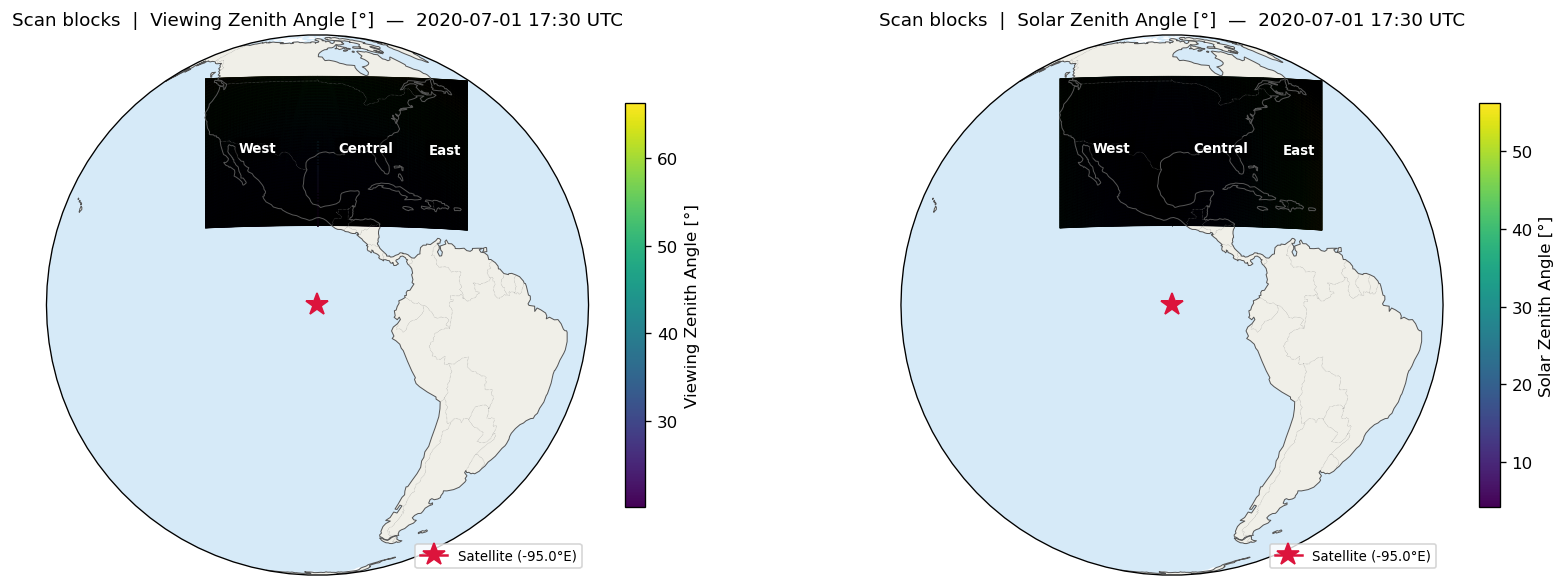

In [8]:
# ---- VZA and SZA side-by-side with footprint polygons ----
import cartopy.crs as ccrs
sat_lon = blocks[0]._meta['sat_lon_deg']
_geo = ccrs.Geostationary(central_longitude=sat_lon, satellite_height=35_786_000)
fig, axes = plt.subplots(1, 2, figsize=(15, 5), subplot_kw={'projection': _geo})
for ax, fld in zip(axes, ['vzas', 'szas']):
    plot_scan_blocks(
        blocks, field=fld, mode='footprints',
        ax=ax, coastlines=True,
        block_labels=['West', 'Central', 'East'],
    )
plt.tight_layout()

Cartopy found: using map projections and basemap features.


/Users/scrowell/miniforge3/envs/analysis/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


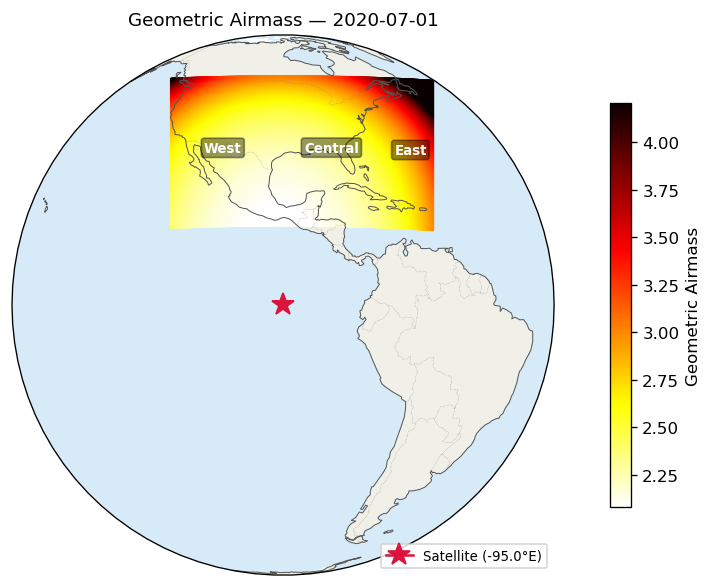

In [9]:
# ---- Geometric airmass with 'pixels' mode (fast) ----
import cartopy.crs as ccrs
sat_lon = blocks[0]._meta['sat_lon_deg']
fig, ax = plt.subplots(figsize=(12, 5),
                       subplot_kw={'projection': ccrs.Geostationary(
                           central_longitude=sat_lon, satellite_height=35_786_000)})
plot_scan_blocks(
    blocks, field='airmass_geometric', mode='pixels',
    ax=ax, cmap='hot_r', coastlines=True,
    block_labels=['West', 'Central', 'East'],
    title='Geometric Airmass — 2020-07-01',
)
plt.tight_layout()

Cartopy found: using map projections and basemap features.
Cartopy found: using map projections and basemap features.


/Users/scrowell/miniforge3/envs/analysis/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/scrowell/miniforge3/envs/analysis/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


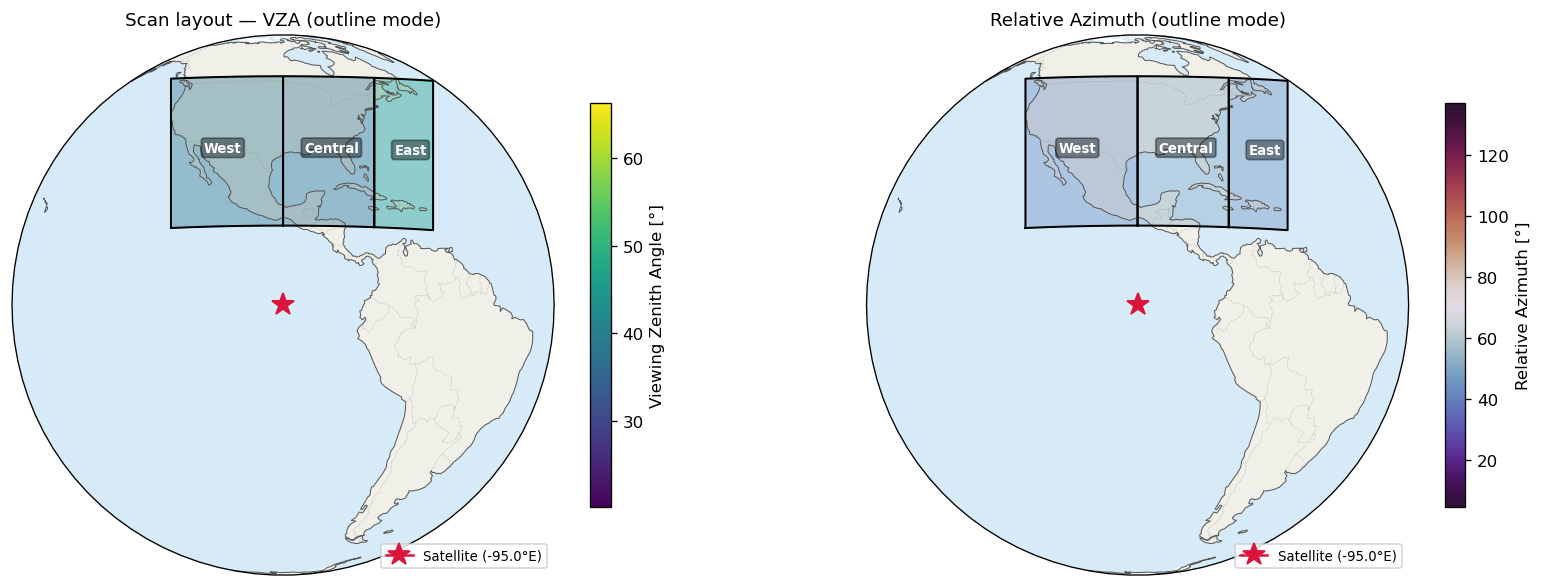

In [10]:
# ---- Block outlines only (useful for scan planning overview) ----
fig, axes = plt.subplots(1, 2, figsize=(15, 5), subplot_kw={'projection': ccrs.Geostationary(central_longitude=-95.0)})
plot_scan_blocks(blocks, field='vzas',            mode='outline',
                 ax=axes[0], coastlines=True,
                 block_labels=['West', 'Central', 'East'],
                 title='Scan layout — VZA (outline mode)')
plot_scan_blocks(blocks, field='relative_azimuth', mode='outline',
                 ax=axes[1], cmap='twilight_shifted', coastlines=True,
                 block_labels=['West', 'Central', 'East'],
                 title='Relative Azimuth (outline mode)')
plt.tight_layout()

---
## 6 — Save and Reload

ScanBlocks can be persisted to a compressed `.npz` file. All arrays and
metadata (including datetimes) round-trip exactly.

In [11]:
import os, tempfile

# Save
save_path = 'west_block.npz'
blocks[0].save(save_path)
size_kb = os.path.getsize(save_path) / 1024
print(f"Saved to {save_path}  ({size_kb:.0f} KB)")

# Reload
reloaded = ScanBlock.load(save_path)
print(f"Reloaded: {reloaded}")

# Verify round-trip
for field in ['vzas', 'szas', 'lats', 'lons']:
    diff = np.abs(reloaded[field] - blocks[0][field]).max()
    print(f"  {field:6s}  max |diff| = {diff:.2e}")

print(f"\nt_start_utc  : {reloaded.t_start_utc}  (type: {type(reloaded.t_start_utc).__name__})")
print(f"t_end_utc    : {reloaded.t_end_utc}")

Saved to west_block.npz  (25081 KB)
Reloaded: ScanBlock(500×402 px | lat=30.0° | lon=[-120.0°,-95.0°] | dur=66.8 min, t=2020-07-01T17:30Z)
  vzas    max |diff| = 0.00e+00
  szas    max |diff| = 0.00e+00
  lats    max |diff| = 0.00e+00
  lons    max |diff| = 0.00e+00

t_start_utc  : 2020-07-01 17:30:00  (type: datetime)
t_end_utc    : 2020-07-01 18:36:50


---
## 7 — Coarsening to a Model Grid

`coarsen_scan_block` (or `block.coarsen()`) bins the fine 6 km pixels onto a
regular lat/lon grid aligned to global multiples of `dlat/dlon`.  This is the
primary interface for feeding geometry to coarse-resolution atmospheric models
(CTMs, reanalysis comparisons, etc.).

Aggregation rules:
- Scalar angles (VZA, SZA, airmass) → **arithmetic mean**
- Azimuth angles (VAA, SAA) → **circular mean** (handles 0°/360° wrap)
- `sat_look_vecs` → vector-averaged then **renormalised**
- `gnd_ecef` → arithmetic mean of ECEF positions
- `corner_lats/lons` → derived from coarse grid edges directly

In [12]:
# Coarsen all three blocks to 0.5° × 0.5°
coarse_blocks = [blk.coarsen(0.5, 0.5) for blk in blocks]

for name, cblk in zip(['West', 'Central', 'East'], coarse_blocks):
    filled   = int((cblk['pixel_counts'] > 0).sum())
    total_px = int(cblk['pixel_counts'].sum())
    print(f"{name:8s}: {cblk}")
    print(f"  {filled} filled cells  |  {total_px:,} fine pixels binned  |  "
          f"mean pixels/cell = {total_px/filled:.1f}")

West    : ScanBlock(76×77 px | lat=33.2° | lon=[-133.5°,-95.0°] | dur=66.8 min, t=2020-07-01T17:30Z [coarsened 0.5°×0.5°])
  4063 filled cells  |  200,665 fine pixels binned  |  mean pixels/cell = 49.4
Central : ScanBlock(75×61 px | lat=32.8° | lon=[-95.5°,-65.0°] | dur=53.3 min, t=2020-07-01T18:36Z [coarsened 0.5°×0.5°])
  3286 filled cells  |  160,500 fine pixels binned  |  mean pixels/cell = 48.8
East    : ScanBlock(81×100 px | lat=34.2° | lon=[-78.0°,-28.0°] | dur=40.0 min, t=2020-07-01T19:30Z [coarsened 0.5°×0.5°])
  2815 filled cells  |  120,500 fine pixels binned  |  mean pixels/cell = 42.8


In [13]:
# Validate coarsening accuracy
print("Field mean comparison (fine vs 0.5° coarse):")
print(f"{'Field':20s}  {'Fine':>9}  {'Coarse':>9}  {'|Δ|':>8}")
print("-" * 52)
for fld in ['vzas', 'szas', 'vaas', 'airmass_geometric']:
    fine_mean   = float(np.nanmean(blocks[0][fld]))
    coarse_mean = float(np.nanmean(coarse_blocks[0][fld]))
    print(f"{fld:20s}  {fine_mean:9.4f}  {coarse_mean:9.4f}  {abs(fine_mean-coarse_mean):8.4f}")

# Validate unit-vector preservation
slv  = coarse_blocks[0]['sat_look_vecs']
mask = np.all(np.isfinite(slv), axis=-1)
norms = np.linalg.norm(slv[mask], axis=-1)
print(f"\nsat_look_vecs norm  min={norms.min():.7f}  max={norms.max():.7f}  (≈1.0)")

# Validate gnd_ecef near-surface altitude
ge = coarse_blocks[0]['gnd_ecef']
mask_g = np.all(np.isfinite(ge), axis=-1)
_, _, alts = ecef_to_geodetic(ge[mask_g])
print(f"gnd_ecef altitude   min={alts.min():.3f} km  max={alts.max():.3f} km  (≈0 km)")

Field mean comparison (fine vs 0.5° coarse):
Field                      Fine     Coarse       |Δ|
----------------------------------------------------
vzas                    39.3652    43.5584    4.1932
szas                    20.9858    23.4351    2.4493
vaas                   155.2157   155.5462    0.3305
airmass_geometric        2.4614     2.5941    0.1327

sat_look_vecs norm  min=1.0000000  max=1.0000000  (≈1.0)
gnd_ecef altitude   min=-0.043 km  max=0.000 km  (≈0 km)


Text(0.5, 1.0, 'West block — pixel coverage at 0.5°×0.5°')

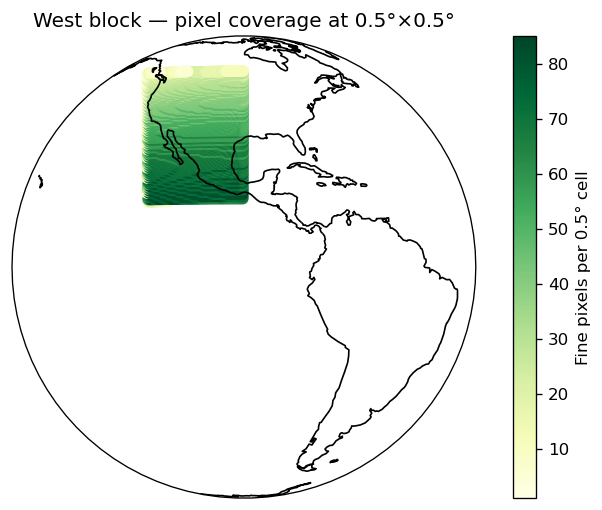

In [18]:
import cartopy.crs as ccrs
# Pixel count map — shows coverage density per 0.5° cell
cblk = coarse_blocks[0]
fig, ax = plt.subplots(figsize=(8, 5),subplot_kw={'projection': ccrs.Geostationary(central_longitude=-95.0)})
ax.coastlines()
ax.set_global()
im = ax.scatter(
    cblk['lons'],                          # cell centres (lon)
    cblk['lats'],                          # cell centres (lat)
    c=cblk['pixel_counts'].astype(float),
    cmap='YlGn',transform=ccrs.PlateCarree()#, shading='auto'
)
plt.colorbar(im, ax=ax, label='Fine pixels per 0.5° cell')
ax.set_xlabel('Longitude [°E]')
ax.set_ylabel('Latitude [°]')
ax.set_title('West block — pixel coverage at 0.5°×0.5°')
#plt.tight_layout()

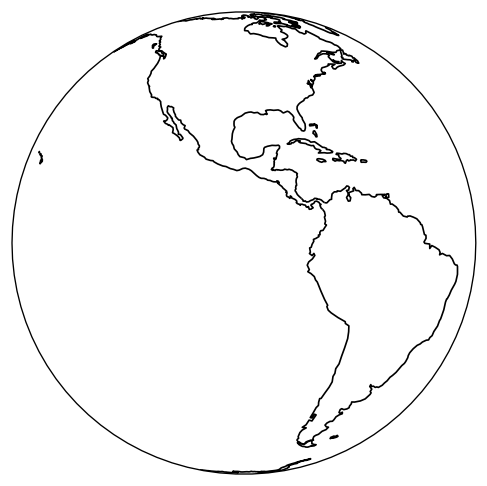

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5),subplot_kw={'projection': ccrs.Geostationary(central_longitude=-95.0)})
ax.coastlines()

---
## 8 — Fine vs Coarse Comparison

Visually compare the fine-resolution footprints to the coarsened grid.

Cartopy found: using map projections and basemap features.
Cartopy found: using map projections and basemap features.


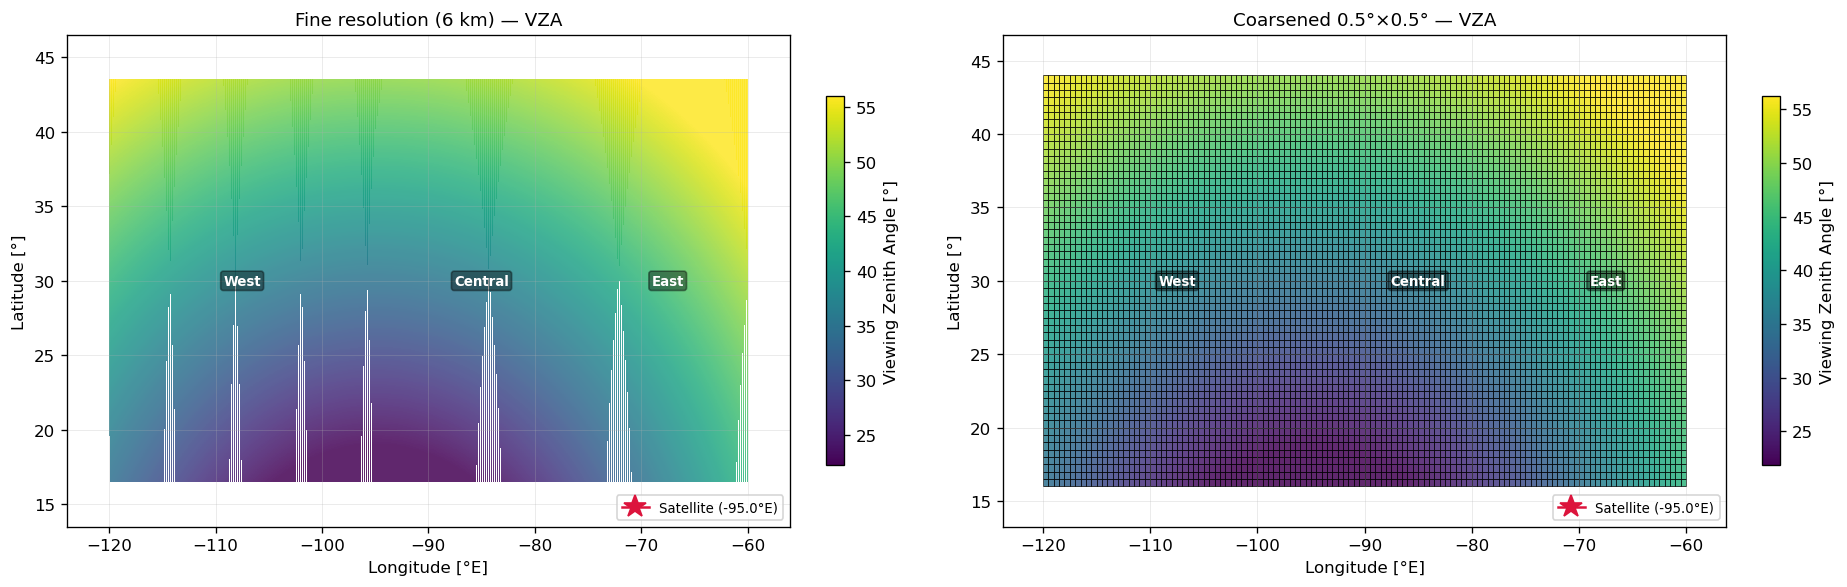

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_scan_blocks(
    blocks, field='vzas', mode='footprints',
    ax=axes[0], coastlines=False,
    block_labels=['West', 'Central', 'East'],
    title='Fine resolution (6 km) — VZA',
    outline_lw=0.0,
)
plot_scan_blocks(
    coarse_blocks, field='vzas', mode='footprints',
    ax=axes[1], coastlines=False,
    block_labels=['West', 'Central', 'East'],
    title='Coarsened 0.5°×0.5° — VZA',
    outline_lw=0.5,
)
plt.tight_layout()

Cartopy found: using map projections and basemap features.
Cartopy found: using map projections and basemap features.
Cartopy found: using map projections and basemap features.
Cartopy found: using map projections and basemap features.


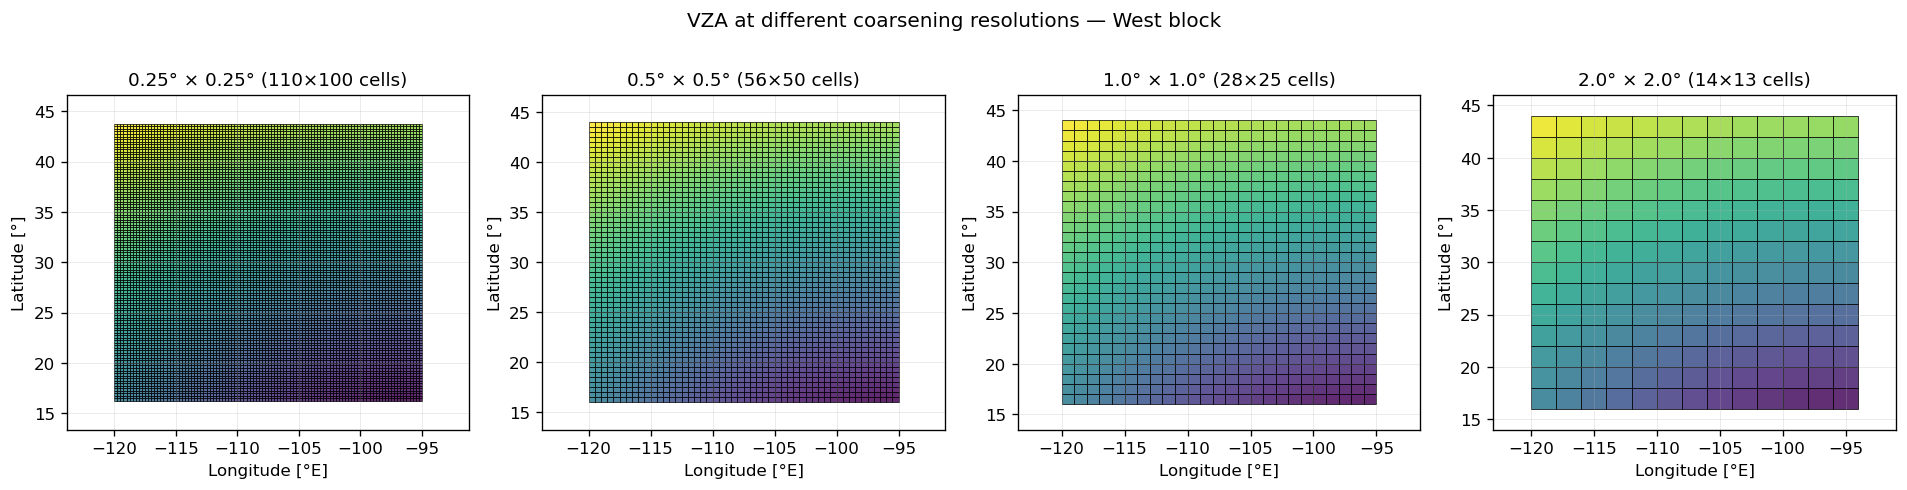

In [ ]:
# Compare a range of coarsening resolutions
blk0   = blocks[0]    # West block
resols = [0.25, 0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, len(resols), figsize=(16, 4))
vmin, vmax = blk0['vzas'].min(), blk0['vzas'].max()

for ax, res in zip(axes, resols):
    cb = blk0.coarsen(res, res)
    plot_scan_blocks(
        cb, field='vzas', mode='footprints',
        ax=ax, coastlines=False,
        vmin=vmin, vmax=vmax,
        show_sat_subpoint=False, show_colorbar=False,
        title=f'{res}° × {res}° ({cb.n_rows}×{cb.n_cols} cells)',
        outline_lw=0.5,
    )
plt.suptitle('VZA at different coarsening resolutions — West block', y=1.01)
plt.tight_layout()

---
## 9 — 3-D Ray Tracing Through the Atmosphere

`compute_ray_paths_vectorized` intersects the satellite-to-ground ray with
spherical atmospheric shells at specified altitudes.  The ray is parameterised
as **P(t) = sat + t × (gnd − sat)**, so t = 0 at the satellite and t = 1 at
the ground.

Returns ECEF intercept points, slant lengths, and geodetic coordinates at
each shell — everything needed to interpolate a 3-D atmospheric model along
the line of sight.

In [ ]:
# Ray paths for every pixel in the West block
blk0   = blocks[0]
alts   = np.arange(0.0, 80.0, 1.0)   # 80 shells, 1 km spacing

t0   = time.perf_counter()
rays = sat.compute_ray_paths_vectorized(
    blk0['lats'].ravel(),
    blk0['lons'].ravel(),
    alts,
)
elapsed = (time.perf_counter() - t0) * 1e3

N, M = len(blk0['lats'].ravel()), len(alts)
print(f"{N:,} pixels × {M} shells  →  {elapsed:.0f} ms")
print(f"intercept_pts shape : {rays['intercept_pts'].shape}")
print(f"slant_lengths shape : {rays['slant_lengths'].shape}")

201,000 pixels × 80 shells  →  2373 ms
intercept_pts shape : (201000, 80, 3)
slant_lengths shape : (201000, 79)


In [ ]:
# Inspect the ray path for the centre pixel
n_rows, n_cols = blk0.shape
flat_idx = (n_rows // 2) * n_cols + (n_cols // 2)   # centre pixel (flat index)

lat_c = blk0['lats'].ravel()[flat_idx]
lon_c = blk0['lons'].ravel()[flat_idx]
vza_c = blk0['vzas'].ravel()[flat_idx]
print(f"Centre pixel: lat={lat_c:.3f}°  lon={lon_c:.3f}°  VZA={vza_c:.2f}°")
print(f"Expected slant length per 1 km layer ≈ 1/cos(VZA) = {1/np.cos(np.deg2rad(vza_c)):.4f} km")
print(f"\nRay path (every 10 km):")
print(f"  {'alt':>6}  {'lat':>8}  {'lon':>9}  {'slant [km]':>11}")
for j in range(0, len(alts), 10):
    sl = f"{rays['slant_lengths'][flat_idx, j]:11.4f}" if j < len(alts)-1 else "         ---"
    print(f"  {alts[j]:6.0f}  "
          f"{rays['lat_intercepts'][flat_idx, j]:8.4f}  "
          f"{rays['lon_intercepts'][flat_idx, j]:9.4f}  {sl}")

Centre pixel: lat=30.027°  lon=-107.469°  VZA=37.56°
Expected slant length per 1 km layer ≈ 1/cos(VZA) = 1.2614 km

Ray path (every 10 km):
     alt       lat        lon   slant [km]
       0   29.9934  -107.4517       1.2582
      10   29.9304  -107.4197       1.2570
      20   29.8676  -107.3879       1.2559
      30   29.8050  -107.3562       1.2548
      40   29.7427  -107.3247       1.2537
      50   29.6806  -107.2934       1.2525
      60   29.6188  -107.2622       1.2514
      70   29.5572  -107.2312       1.2503


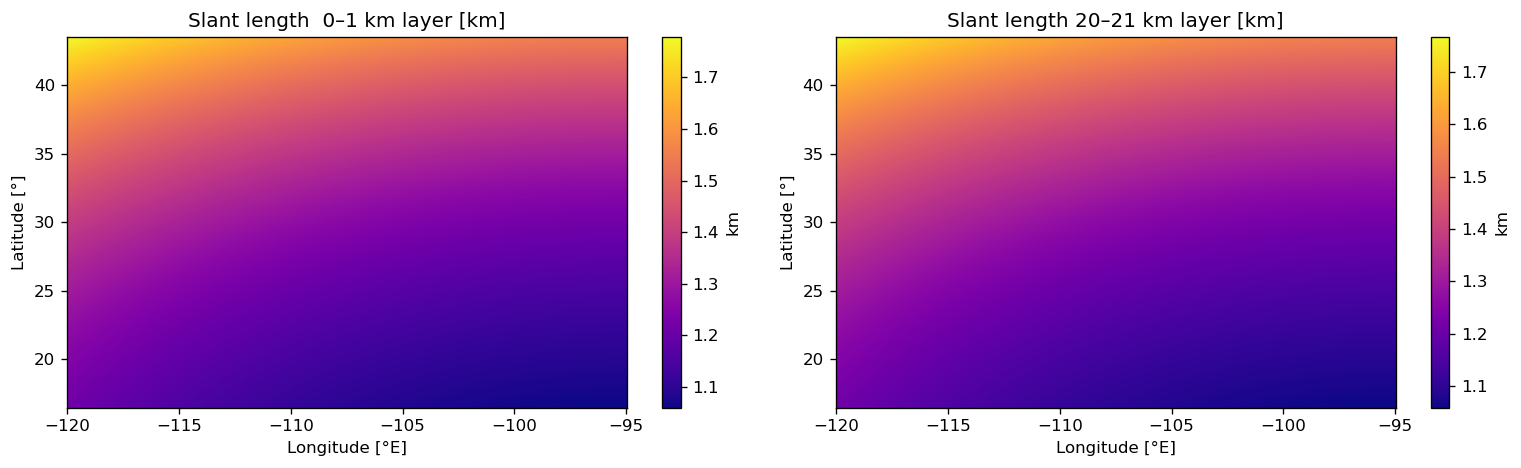

In [ ]:
# Slant length map at a specific altitude layer (e.g. 0-1 km boundary layer)
slant_bl = rays['slant_lengths'][:, 0].reshape(n_rows, n_cols)   # 0→1 km layer
slant_ut = rays['slant_lengths'][:, 20].reshape(n_rows, n_cols)  # 20→21 km (stratosphere)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, data, title in zip(
        axes,
        [slant_bl, slant_ut],
        ['Slant length  0–1 km layer [km]', 'Slant length 20–21 km layer [km]']):
    im = ax.pcolormesh(blk0['lons'], blk0['lats'], data,
                       cmap='plasma', shading='auto')
    plt.colorbar(im, ax=ax, label='km')
    ax.set_xlabel('Longitude [°E]')
    ax.set_ylabel('Latitude [°]')
    ax.set_title(title)
plt.tight_layout()

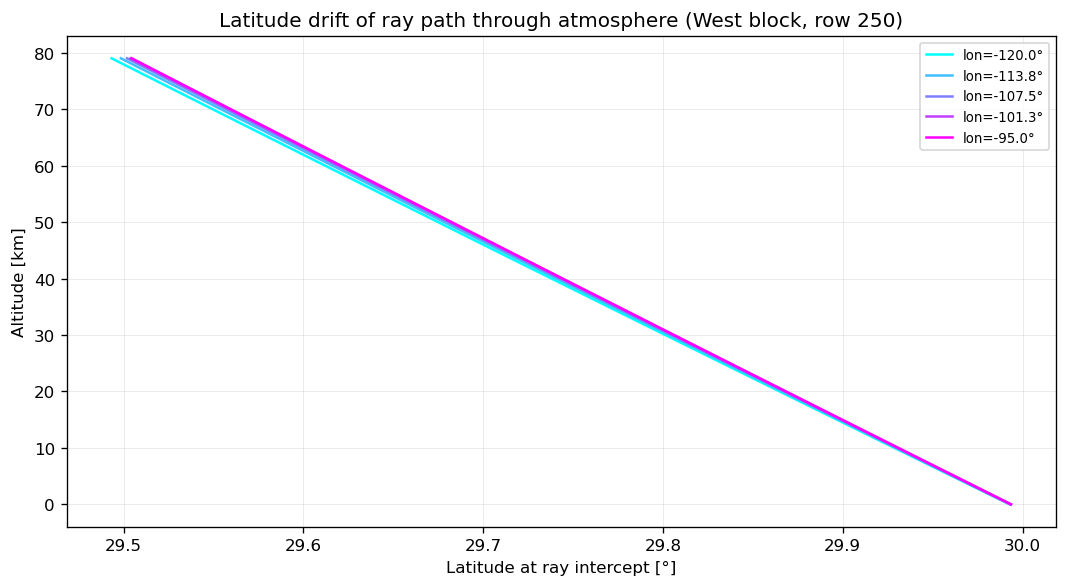

In [ ]:
# Side-view of a ray path through the atmosphere
# Show the latitude drift of the ray as it passes through different altitudes
row_mid = n_rows // 2
col_subset = np.linspace(0, n_cols - 1, 5, dtype=int)   # 5 example columns

fig, ax = plt.subplots(figsize=(9, 5))
cmap_r = plt.cm.cool

for i, col in enumerate(col_subset):
    px = row_mid * n_cols + col
    lat_path = rays['lat_intercepts'][px]
    color    = cmap_r(i / (len(col_subset) - 1))
    ax.plot(lat_path, alts, color=color, lw=1.5,
            label=f"lon={blk0['lons'].ravel()[px]:.1f}°")

ax.set_xlabel('Latitude at ray intercept [°]')
ax.set_ylabel('Altitude [km]')
ax.set_title('Latitude drift of ray path through atmosphere (West block, row 250)')
ax.legend(fontsize=8)
ax.grid(True, lw=0.3, alpha=0.5)
plt.tight_layout()

---
## 10 — Ray Tracing from a ScanBlock

For coarser atmospheric model runs, compute ray paths from a coarsened
ScanBlock.  This significantly reduces the number of rays needed.

The `sat_look_vecs` (unit vectors) and `gnd_ecef` (ground position) from each
coarse cell provide everything needed for radiative transfer:
- **Entry point** of each atmospheric layer along the mean look direction
- **Slant path length** through each layer
- **Lat/lon** at each intercept for model interpolation

In [ ]:
# Build ray paths for the coarsened West block (0.5° × 0.5°)
cblk = coarse_blocks[0]

# Mask NaN cells before passing to ray tracer
valid = np.isfinite(cblk['lats']) & np.isfinite(cblk['lons'])
lats_v = cblk['lats'][valid]
lons_v = cblk['lons'][valid]

t0 = time.perf_counter()
rays_c = sat.compute_ray_paths_vectorized(lats_v, lons_v, alts)
elapsed = (time.perf_counter() - t0) * 1e3
print(f"Coarse ray paths: {len(lats_v):,} cells × {len(alts)} shells  →  {elapsed:.0f} ms")
print(f"Speed-up vs fine: {N / len(lats_v):.0f}×  ({N:,} fine → {len(lats_v):,} coarse pixels)")

Coarse ray paths: 2,800 cells × 80 shells  →  21 ms
Speed-up vs fine: 72×  (201,000 fine → 2,800 coarse pixels)


In [ ]:
# Summary table for atmospheric model input
print("Coarsened ScanBlock fields for 3-D model input:")
print(f"{'Field':22s}  {'Shape':15s}  Description")
print("-" * 75)
rows = [
    ('lats / lons',       f"{cblk.shape}",           'Grid cell centres [°]'),
    ('vzas / szas',       f"{cblk.shape}",           'Viewing / solar zenith [°]'),
    ('vaas / saas',       f"{cblk.shape}",           'Viewing / solar azimuth [°]'),
    ('sat_look_vecs',     f"{cblk['sat_look_vecs'].shape}", 'Unit look vec sat→gnd (ECEF)'),
    ('gnd_ecef',          f"{cblk['gnd_ecef'].shape}",      'Ground ECEF position [km]'),
    ('corner_lats/lons',  f"{cblk['corner_lats'].shape}",   'Cell boundary polygons [°]'),
    ('pixel_counts',      f"{cblk['pixel_counts'].shape}",  'Fine pixels per cell'),
    ('intercept_pts',     f"{rays_c['intercept_pts'].shape}", 'Shell entry ECEF [km]'),
    ('slant_lengths',     f"{rays_c['slant_lengths'].shape}", 'Layer path length [km]'),
    ('lat/lon_intercepts',f"{rays_c['lat_intercepts'].shape}", 'Shell lat/lon [°]'),
]
for name, shape, desc in rows:
    print(f"  {name:22s}  {shape:15s}  {desc}")

Coarsened ScanBlock fields for 3-D model input:
Field                   Shape            Description
---------------------------------------------------------------------------
  lats / lons             (56, 50)         Grid cell centres [°]
  vzas / szas             (56, 50)         Viewing / solar zenith [°]
  vaas / saas             (56, 50)         Viewing / solar azimuth [°]
  sat_look_vecs           (56, 50, 3)      Unit look vec sat→gnd (ECEF)
  gnd_ecef                (56, 50, 3)      Ground ECEF position [km]
  corner_lats/lons        (56, 50, 4)      Cell boundary polygons [°]
  pixel_counts            (56, 50)         Fine pixels per cell
  intercept_pts           (2800, 80, 3)    Shell entry ECEF [km]
  slant_lengths           (2800, 79)       Layer path length [km]
  lat/lon_intercepts      (2800, 80)       Shell lat/lon [°]


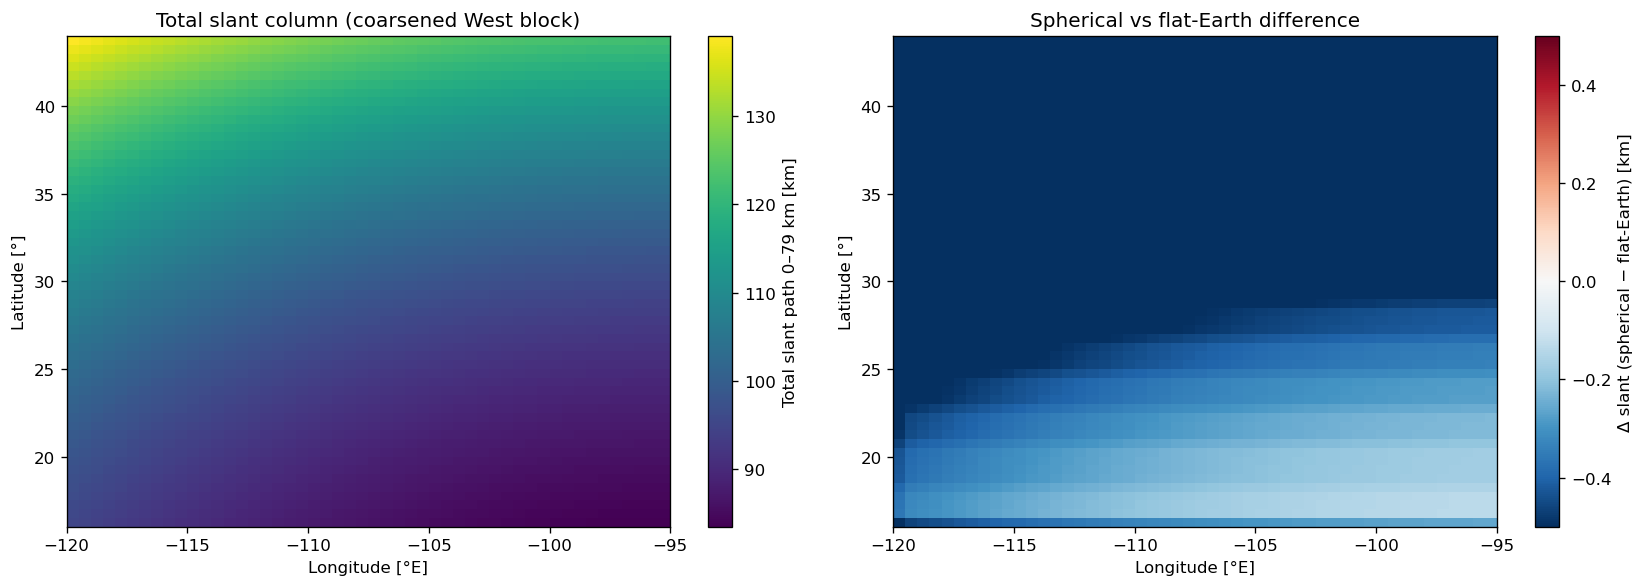

In [ ]:
# Mean slant column (total path length through 0-79 km atmosphere)
# for each valid coarse cell — reshape back to 2-D grid
total_slant = rays_c['slant_lengths'].sum(axis=1)  # (n_valid,) total slant [km]

slant_2d = np.full(cblk.shape, np.nan)
slant_2d[valid] = total_slant

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total slant column
im0 = axes[0].pcolormesh(cblk['lons'], cblk['lats'], slant_2d,
                          cmap='viridis', shading='auto')
plt.colorbar(im0, ax=axes[0], label='Total slant path 0–79 km [km]')
axes[0].set_title('Total slant column (coarsened West block)')
axes[0].set_xlabel('Longitude [°E]');  axes[0].set_ylabel('Latitude [°]')

# Compare total slant column vs sec(VZA) * 79 km (flat-Earth expectation)
secvza_2d = np.full(cblk.shape, np.nan)
secvza_2d[valid] = 1.0 / np.cos(np.deg2rad(cblk['vzas'][valid])) * 79.0
diff = slant_2d - secvza_2d
im1 = axes[1].pcolormesh(cblk['lons'], cblk['lats'], diff,
                          cmap='RdBu_r', shading='auto',
                          vmin=-0.5, vmax=0.5)
plt.colorbar(im1, ax=axes[1], label='Δ slant (spherical − flat-Earth) [km]')
axes[1].set_title('Spherical vs flat-Earth difference')
axes[1].set_xlabel('Longitude [°E]');  axes[1].set_ylabel('Latitude [°]')
plt.tight_layout()